In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.count("/") - 2
    if depth > 3:
        dirs[:] = []          # don't descend into the DICOM tree
        continue
    dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

/kaggle/input/competitions/rsna-knee-abnormality-detection/test_series.csv
/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv
/kaggle/input/competitions/rsna-knee-abnormality-detection/sample_submission.csv
/kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv
/kaggle/input/competitions/rsna-knee-abnormality-detection/test.csv


In [2]:
import os
import numpy as np
import pandas as pd
import pydicom
from pathlib import Path
 
ROOT = Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")
BASE = ROOT / "train_series"

In [3]:
R = "/kaggle/input/competitions/rsna-knee-abnormality-detection/"

for name in ["train", "train_series", "test", "test_series", "sample_submission"]:
    df = pd.read_csv(R + name + ".csv")
    print(f"=== {name} === {df.shape}")
    print(df.columns.tolist())
    print(df.head(3), "\n")

=== train === (4407, 14)
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
                                    StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...   
2  1.2.826.0.1.3680043.8.498.10009278692606631573...   

                                              Report  ACL  MCL  \
0  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN   
1  [DATE]: * MR Knie Rechts 15ch AA Klinische Inl...  NaN  NaN   
2  Hallazgos:\nNo hay alteraciones en significati...  NaN  NaN   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  \
0              NaN               NaN        NaN         NaN    NaN       NaN   
1              NaN               NaN        NaN         NaN    NaN       NaN   
2              NaN               NaN        NaN         NaN    N

In [4]:
CROP_MM = 130.0            # physical width of the crop, in millimetres
OUT_SIZE = 336             # pixels per side after resize (14 x 24, DINOv2 patch)
N_SLICE = 9                # slices sampled per series (divisible by 3 for RGB groups)
SLICE_BAND = (0.20, 0.80)  # sample across this fraction of the ordered stack
LAT_MIN_OFFSET_MM = 20.0   # inside this distance from midline, decline to guess side
 
# Header fields worth reading. Each is used below; if you add one, add the
# reason too, or it becomes cargo cult.
HDR_TAGS = [
    "SeriesDescription", "SequenceName", "ScanOptions", "ScanningSequence",
    "RepetitionTime", "EchoTime",        # -> pulse-sequence weighting
    "Laterality",                        # -> which knee, when present
    "PixelSpacing", "Rows", "Columns",   # -> mm per pixel, for the crop
    "RescaleSlope", "RescaleIntercept",  # -> stored value to real intensity
    "ImagePositionPatient",              # -> where the image sits in the patient
    "ImageOrientationPatient",           # -> which way it faces (plane, side)
]

In [5]:
def _vec(s, n):
    """Parse a '|'-joined multi-value header back into floats."""
    if not isinstance(s, str):
        return None
    try:
        v = [float(x) for x in s.split("|")]
    except ValueError:
        return None
    return np.array(v) if len(v) >= n else None
 
 
def probe_series(series_dir):
    """One header read per series, no pixel data.
 
    stop_before_pixels=True is the whole trick for working at this scale. A
    header is a few kB; the pixel data behind it is megabytes. You can scan the
    corpus's headers in minutes and decide from that index which series are
    worth decoding.
 
    The MIDDLE file is read, not the first: on a sagittal knee stack the first
    slice can sit off the edge of the joint, and some vendors write thinner
    headers on the end slices. force=True because a minority of files here lack
    the standard preamble and pydicom refuses them otherwise.
    """
    series_dir = Path(series_dir)
    files = sorted(e.name for e in os.scandir(series_dir) if e.name.endswith(".dcm"))
    row = {"dir": str(series_dir), "SeriesInstanceUID": series_dir.name,
           "files": files, "n_slices": len(files)}
    if not files:
        return row
 
    ds = pydicom.dcmread(series_dir / files[len(files) // 2],
                         stop_before_pixels=True, force=True)
    for t in HDR_TAGS:
        v = getattr(ds, t, None)
        if v is None:
            row[t] = None
        elif isinstance(v, (list, tuple)) or type(v).__name__ == "MultiValue":
            # PixelSpacing / ImagePositionPatient are multi-valued. Joining keeps
            # the frame flat and printable; _vec() reverses it.
            row[t] = "|".join(str(x) for x in v)
        else:
            row[t] = str(v)
    return row
 
 
def scan_study(study_dir):
    """Index every series directory in one study."""
    rows = [probe_series(s.path) for s in os.scandir(study_dir) if s.is_dir()]
    return pd.DataFrame(rows) 

In [6]:
def plane_of(iop):
    """Sagittal / Coronal / Axial, from the direction cosines.
 
    ImageOrientationPatient holds two unit vectors: the direction image rows run
    in, and the direction columns run in. Their cross product is the slice
    normal, and whichever patient axis it points most strongly along names the
    plane.
 
    This is read from geometry rather than from SeriesDescription because the
    description is free text written by whoever configured the scanner. Across
    16 sites you will meet 'SAG PD FS', 'sag_pd_fs', 't2_tse_sag', and plenty in
    languages other than English. Direction cosines mean the same thing
    everywhere.
    """
    if iop is None:
        return "Unknown"
    normal = np.cross(iop[0:3], iop[3:6])
    return {0: "Sagittal", 1: "Coronal", 2: "Axial"}[int(np.argmax(np.abs(normal)))]
 
 
def weighting_of(row):
    """Rough T1 / T2 / PD guess - deliberately left thin.
 
    The serious version combines description text, ScanOptions tokens, TR and TE
    with tuned regexes. This is one of the places worth improving yourself: what
    counts as fluid-sensitive decides which series feeds which model input, and
    there is real headroom in doing it well.
    """
    desc = f"{row.get('SeriesDescription') or ''} {row.get('SequenceName') or ''}".lower()
    te = pd.to_numeric(row.get("EchoTime"), errors="coerce")
    tr = pd.to_numeric(row.get("RepetitionTime"), errors="coerce")
 
    if "t1" in desc:
        return "T1"
    if "pd" in desc:
        return "PD"
    if "t2" in desc or "stir" in desc:
        return "T2"
    if np.isfinite(te) and np.isfinite(tr):      # fall back to timings
        if te < 30 and tr < 800:
            return "T1"
        if te > 60:
            return "T2"
        return "PD"
    return "Unknown"
 
 
def fatsat_of(row):
    """Fat suppression: substring on the description, WHOLE TOKEN on ScanOptions.
 
    GE writes 'SAT_GEMS' in ScanOptions for *spatial* saturation, which has
    nothing to do with fat saturation. A substring test for 'SAT' fires on series
    that are not fat-sat at all, so ScanOptions must be matched as exact tokens.
    """
    desc = f"{row.get('SeriesDescription') or ''} {row.get('SequenceName') or ''}".lower()
    text_hit = any(k in desc for k in ("fs", "fatsat", "fat_sat", "stir", "spair", "spir"))
    opts = (row.get("ScanOptions") or "").upper().split("|")
    opt_hit = any(t.strip() in {"FS", "FAT_SAT", "SAT1", "FSAT"} for t in opts)
    return bool(text_hit or opt_hit)


In [7]:
def side_from_geometry(df):
    """'L' / 'R' / None from where the image sits in the patient.
 
    Laterality (0020,0060) is Type 2C: legitimately allowed to be absent, and in
    this corpus it is missing on about half the studies - missing by whole
    vendor, not scattered at random. If you treat 'tag absent' as 'left knee',
    half the corpus never gets mirrored, and every finding with a side to it
    (both menisci, both tibiofemoral compartments, the MCL) has its axis reversed
    on a large minority of your training data. Nothing crashes. The model just
    learns worse.
 
    The patient coordinate system recovers it: +x points to the patient's LEFT,
    so a right knee sits at negative x.
 
    Two details that are easy to get wrong:
      - Use the image CENTRE, not ImagePositionPatient itself. IPP is the corner
        of the image, offset by half a field of view - enough to flip the sign on
        a knee scanned near the midline.
      - Take the MEDIAN across the study's series, not one series: a single
        sagittal slice can sit anywhere across the joint.
 
    Near the midline it returns None rather than guessing. A study you know you
    do not know about is more useful than a coin flip you trust.
    """
    tagged = df["Laterality"].dropna().unique()
    if len(tagged) == 1 and str(tagged[0]).upper() in ("L", "R"):
        return str(tagged[0]).upper()
 
    centres = []
    for r in df.to_dict("records"):
        ipp = _vec(r.get("ImagePositionPatient"), 3)
        iop = _vec(r.get("ImageOrientationPatient"), 6)
        ps = _vec(r.get("PixelSpacing"), 2)
        rows, cols = r.get("Rows"), r.get("Columns")
        if ipp is None or iop is None or ps is None or not rows or not cols:
            continue
        centre = (ipp[:3]
                  + iop[0:3] * ps[1] * float(cols) / 2
                  + iop[3:6] * ps[0] * float(rows) / 2)
        centres.append(float(centre[0]))
 
    if not centres:
        return None
    m = float(np.median(centres))
    return None if abs(m) < LAT_MIN_OFFSET_MM else ("R" if m < 0 else "L")
 
 
def normalise_laterality(vol, plane, side):
    """Map every knee onto a left-knee convention.
 
    Coronal and axial views of a right knee are mirror images of a left knee, so
    a horizontal flip corrects them.
 
    Sagittal stacks are NOT. Flipping a sagittal image left-right swaps anterior
    and posterior, which is not the difference between knees. What differs is
    that the slice order runs medial-to-lateral in opposite directions - so the
    SLICE axis is reversed, not the image axis.
 
    Getting this backwards is invisible in any shape check and in any montage
    unless you know knee anatomy well enough to spot it.
    """
    if side != "R":
        return vol
    if plane in ("Coronal", "Axial"):
        return vol[:, :, ::-1]
    return vol[::-1]

In [8]:
def order_slices(series_dir, files):
    """Sort a stack into spatial order, with fallbacks.
 
    Filenames are not a reliable order (look at them - they are UIDs), and
    neither, on its own, is InstanceNumber. The dependable key is position along
    the slice normal: project ImagePositionPatient onto that normal and sort.
 
    Fallback chain: position -> InstanceNumber -> natural filename order. Each is
    worse than the last, so the log prints which one was used. A study that
    silently fell through to filename order is worth knowing about.
    """
    series_dir = Path(series_dir)
    keys, kind = [], "position"
    for f in files:
        try:
            ds = pydicom.dcmread(series_dir / f, stop_before_pixels=True, force=True)
            ipp = np.array([float(x) for x in ds.ImagePositionPatient])
            iop = np.array([float(x) for x in ds.ImageOrientationPatient])
            keys.append(float(np.dot(ipp, np.cross(iop[0:3], iop[3:6]))))
        except Exception:
            keys = []
            break
 
    if not keys:
        kind = "instance"
        try:
            keys = [int(pydicom.dcmread(series_dir / f, stop_before_pixels=True,
                                        force=True).InstanceNumber) for f in files]
        except Exception:
            kind, keys = "filename", list(range(len(files)))
 
    print(f"      slice order from: {kind}")
    return [f for _, f in sorted(zip(keys, files))]

In [9]:
def _resize(a, size):
    """Bilinear resize in numpy, so this needs neither torch nor cv2."""
    h, w = a.shape
    yi, xi = np.linspace(0, h - 1, size), np.linspace(0, w - 1, size)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, h - 1); wy = (yi - y0)[:, None]
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, w - 1); wx = (xi - x0)[None, :]
    top = a[np.ix_(y0, x0)] * (1 - wx) + a[np.ix_(y0, x1)] * wx
    bot = a[np.ix_(y1, x0)] * (1 - wx) + a[np.ix_(y1, x1)] * wx
    return top * (1 - wy) + bot * wy
 
 
def read_series(series_dir, files, pixel_spacing, n_slice=N_SLICE, out_size=OUT_SIZE):
    """Decode n_slice physically-spread slices into [n_slice, out, out] in [0,1]."""
    series_dir = Path(series_dir)
    n = len(files)
    if n == 0:
        return None
 
    # (a) Sample across a CENTRAL BAND, not the whole stack. The outermost slices
    #     of a knee series are mostly soft tissue outside the joint. This is a
    #     knob for a reason: right at 3 slices, questionable at 16 - and a Baker's
    #     cyst sits at the posteromedial end of a sagittal stack, exactly where
    #     this crops away.
    lo, hi = int(SLICE_BAND[0] * (n - 1)), int(SLICE_BAND[1] * (n - 1))
    idx = np.unique(np.linspace(lo, hi, n_slice).astype(int)) if hi > lo else np.array([n // 2])
    while len(idx) < n_slice:
        idx = np.append(idx, idx[-1])       # short stack: repeat the last slice
    idx = idx[:n_slice]
 
    planes, failed = [], []
    for k, i in enumerate(idx):
        try:
            ds = pydicom.dcmread(series_dir / files[int(i)], force=True)
            a = ds.pixel_array.astype(np.float32)
            # (b) Stored value -> real intensity. On MR slope/intercept are
            #     usually 1/0 so this looks like a no-op, but it is not always,
            #     and it costs one line. (On CT this same step is what gives you
            #     Hounsfield Units, where it is mandatory.)
            a = a * float(getattr(ds, "RescaleSlope", 1) or 1) \
                  + float(getattr(ds, "RescaleIntercept", 0) or 0)
            planes.append(a)
        except Exception:
            planes.append(None)
            failed.append(k)
 
    # (c) A slice that will not decode has NO SHAPE OF ITS OWN. Do not invent a
    #     zero plane at the output size: the shape check below would then treat
    #     the substitute as the authority and blank the good slices with it,
    #     giving a black series that every downstream check still reports as
    #     present. Fill from the nearest slice that did decode; if nothing
    #     decoded, report absent - a state you can express.
    got = [k for k, p in enumerate(planes) if p is not None]
    if not got:
        print(f"      DECODE FAILED for whole series {series_dir.name}")
        return None
    if failed:
        print(f"      {len(failed)} slice(s) failed to decode; filled from neighbours")
        for k in failed:
            planes[k] = planes[min(got, key=lambda j: abs(j - k))]
 
    # (d) Slices within one series can still differ in matrix size - multi-echo
    #     series and some reformats do. Those are genuinely not stackable.
    shp = planes[0].shape
    planes = [p if p.shape == shp else np.zeros(shp, np.float32) for p in planes]
    vol = np.stack(planes)
 
    # (e) Crop a constant PHYSICAL extent, then resize - not a constant pixel box.
    #     PixelSpacing varies ~3.4x across this corpus, so a fixed 224px crop
    #     grabs ~90 mm of knee on one scanner and ~300 mm on another, and the
    #     model must learn a scale invariance it was never given the information
    #     to learn. Millimetres make a pixel mean the same thing everywhere.
    if pixel_spacing and np.isfinite(pixel_spacing) and pixel_spacing > 0:
        want = int(round(CROP_MM / pixel_spacing))
        h, w = shp
        if 16 < want < min(h, w):
            cy, cx, half = h // 2, w // 2, want // 2
            vol = vol[:, max(0, cy - half):cy + half, max(0, cx - half):cx + half]
 
    # (f) Percentile normalisation, PER SERIES. MR intensity has no absolute
    #     scale - the same tissue on the same scanner reads differently between
    #     sequences - so min/max would let one bright vessel compress everything
    #     else into a narrow band. 1st-99th percentile clips that off.
    lo_v, hi_v = np.percentile(vol, [1, 99])
    vol = np.clip((vol - lo_v) / max(hi_v - lo_v, 1e-6), 0, 1)
 
    return np.stack([_resize(s, out_size) for s in vol])

In [10]:
studies = sorted(d.name for d in os.scandir(BASE) if d.is_dir())
print(f"{len(studies)} studies under {BASE}")
 
df = None      # last series table, left in globals so you can poke at it
vol = None     # last decoded volume
 
 
def main(study_uid=None, show=True):
    global df, vol
 
    study = study_uid or studies[0]
    print(f"study : {study}\n")
 
    df = scan_study(BASE / study)
    df["plane"] = [plane_of(_vec(r.get("ImageOrientationPatient"), 6))
                   for r in df.to_dict("records")]
    df["weight"] = [weighting_of(r) for r in df.to_dict("records")]
    df["fatsat"] = [fatsat_of(r) for r in df.to_dict("records")]
 
    print("Series in this study:")
    print(df[["n_slices", "plane", "weight", "fatsat", "SeriesDescription",
              "PixelSpacing"]].to_string(index=False, max_colwidth=30))
 
    side = side_from_geometry(df)
    tagged = df["Laterality"].dropna().unique()
    print(f"\nlaterality: {side}   "
          f"(Laterality tag: {list(tagged) if len(tagged) else 'ABSENT'})")
 
    # Preferring a thick sagittal fat-sat stack is a PLACEHOLDER for a real
    # selection policy. Which series a model needs, and what to do when a study
    # is missing one, is a design question worth working out yourself.
    pref = df[(df["plane"] == "Sagittal") & df["fatsat"]]
    pick = (pref if len(pref) else df).sort_values("n_slices", ascending=False).iloc[0]
    print(f"\npicked : {pick['plane']} / {pick['weight']} / "
          f"fatsat={pick['fatsat']} / {pick['n_slices']} slices")
 
    ordered = order_slices(pick["dir"], pick["files"])
 
    ps = _vec(pick.get("PixelSpacing"), 2)
    ps_val = float(ps[0]) if ps is not None else None
    px = int(round(CROP_MM / ps_val)) if ps_val else "?"
    print(f"      pixel spacing: {ps_val} mm -> {CROP_MM}mm crop = {px} px "
          f"-> resized to {OUT_SIZE}")
 
    vol = read_series(pick["dir"], ordered, ps_val)
    if vol is None:
        print("nothing decoded; try another study")
        return
 
    print(f"      decoded {vol.shape}  range [{vol.min():.3f}, {vol.max():.3f}]")
    vol = normalise_laterality(vol, pick["plane"], side)
    print(f"      laterality normalised (side={side}, plane={pick['plane']})")
 
    if show:
        import matplotlib.pyplot as plt
        cols = min(len(vol), 5)
        rows = int(np.ceil(len(vol) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
        axes = np.atleast_1d(axes).ravel()
        for ax, sl in zip(axes, vol):
            ax.imshow(sl, cmap="gray"); ax.axis("off")
        for ax in axes[len(vol):]:
            ax.axis("off")
        fig.suptitle(f"{pick['plane']} {pick['weight']} "
                     f"fatsat={pick['fatsat']} side={side}")
        fig.tight_layout()
        plt.show()
 
    return vol

4407 studies under /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series


study : 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260

Series in this study:
 n_slices    plane weight  fatsat SeriesDescription                   PixelSpacing
       18    Axial     T2    True       STIR CS_ AX 0.28771233558654|0.28771233...
       22 Sagittal     PD   False         DP CS_SAG 0.26406249403953|0.26406249...
       16  Coronal     PD    True       DP SPAIR_CS 0.30745044350624|0.30745044...
       16  Coronal     T1   False         T1_TSE_CS 0.29891017079353|0.29891017...
       22 Sagittal     PD    True    DP SPIR CS_SAG        0.330078125|0.330078125

laterality: R   (Laterality tag: [''])

picked : Sagittal / PD / fatsat=True / 22 slices
      slice order from: position
      pixel spacing: 0.330078125 mm -> 130.0mm crop = 394 px -> resized to 336
      decoded (9, 336, 336)  range [0.000, 1.000]
      laterality normalised (side=R, plane=Sagittal)


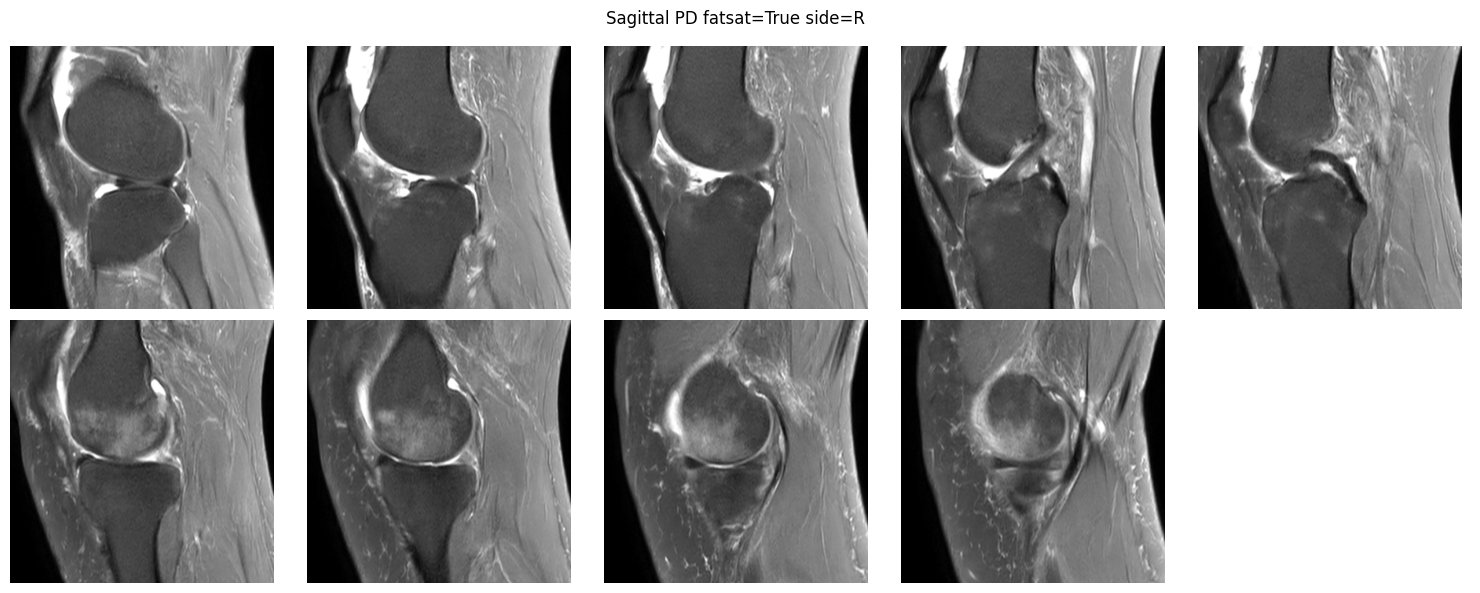

array([[[7.27802057e-03, 8.22959505e-03, 5.82241645e-03, ...,
         2.91120823e-03, 1.70761915e-03, 4.36681234e-03],
        [8.98564017e-03, 8.43797764e-03, 5.95023986e-03, ...,
         5.65766632e-03, 3.87563593e-03, 8.98564017e-03],
        [9.68519890e-03, 7.39606455e-03, 6.83047681e-03, ...,
         8.46061048e-03, 5.83219614e-03, 9.68519890e-03],
        ...,
        [5.04030081e-04, 0.00000000e+00, 0.00000000e+00, ...,
         1.00000000e+00, 9.39450527e-01, 8.52145417e-01],
        [0.00000000e+00, 1.20358907e-03, 7.86823902e-04, ...,
         1.00000000e+00, 9.31650553e-01, 8.40192101e-01],
        [0.00000000e+00, 1.45560411e-03, 9.51574033e-04, ...,
         9.94290592e-01, 9.17847446e-01, 8.29694356e-01]],

       [[8.73362523e-03, 1.50035851e-02, 1.06932587e-02, ...,
         6.26996041e-03, 6.07443150e-03, 4.36681234e-03],
        [1.04412437e-02, 1.80893241e-02, 1.34299373e-02, ...,
         5.40565128e-03, 7.23438819e-03, 7.78205065e-03],
        [1.21488626e-02, 

In [11]:
main()

In [12]:
import pandas as pd
train = pd.read_csv(ROOT / "train.csv")
sub = pd.read_csv(ROOT / "sample_submission.csv")
print(train.shape, train.columns.tolist())
print(train.head())
print(sub.shape, sub.columns.tolist())
print(sub.head())

(4407, 14) ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
                                    StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...   
2  1.2.826.0.1.3680043.8.498.10009278692606631573...   
3  1.2.826.0.1.3680043.8.498.10009639203170750274...   
4  1.2.826.0.1.3680043.8.498.10013663742400736029...   

                                              Report  ACL  MCL  \
0  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN   
1  [DATE]: * MR Knie Rechts 15ch AA Klinische Inl...  NaN  NaN   
2  Hallazgos:\nNo hay alteraciones en significati...  NaN  NaN   
3   In the medial compartment, the meniscus is no...  NaN  NaN   
4  CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...  NaN  NaN   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusi

In [13]:
for r in train.Report.head(20):
    print(r[:600], "\n" + "-"*80)

Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. 
--------------------------------------------------------------------------------
[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor pd gewogen seq fs, cor T1 gewogen seq Bevindingen: 
--------------------------------------------------------------------------------
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento de señal del cuerno posterior del menisco medial que no impresiona contactar con la
superficie articular, sin caracteres propios 

In [14]:
gold = train[train["ACL"].notna()].copy()           # the 58
gold[["StudyInstanceUID", "Report"]].to_csv("/kaggle/working/blind_58.csv", index=False)
gold.to_csv("/kaggle/working/answers_58.csv", index=False)   # don't open this
print(gold["Report"].str.len().describe())

count      58.000000
mean     1305.086207
std       780.291180
min       183.000000
25%       818.250000
50%      1205.500000
75%      1777.250000
max      3891.000000
Name: Report, dtype: float64


In [15]:
for r in gold.Report.head(58):
    print(r[:60000], "\n" + "-"*80)

Antecedentes Clínicos:
Esguince rodilla. [DATE].
Hallazgos:
No hay alteraciones de señal significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Amputación marginal del cuerpo del menisco lateral. Menisco medial de morfología y señal
conservada, sin signos de rotura.
Cartílagos de los compartimentos femorotibiales sin alteraciones.
Fina úlcera condral focal de espesor total del aspecto inferior de la vertiente medial de la tróclea
femoral con mínimos cambios óseos secundarios. Fenómenos condrales reparativos de la región
central de la simple femoral. Cartílago rotuliano sin alteraciones.
Leve derrame articular. No hay quistes poplíteos patológicos.
Aumento de señal de la inserción distal del tendón cuadricipital y de la inserción proximal del
tendón rotuliano, sin signos de rotura.
No hay alteraciones de señal de la grasa de Hoffa.
Impresión:
Amputación marginal del cuerpo del menisco lateral.
Condropatía focal grado 4 del aspecto inferior de la 